# 03 — NDMM PBMC QC Filtering
### By [Mansi Singh](mansi.singh@alleninstitute.org), Comp Bio, Allen Institute for Immunology


**Main aim**: Apply quality control filtering (predicted doublet removal, mitochondrial content thresholds, gene count thresholds) to the NDMM PBMC raw scRNA-seq AnnData object (193 samples) and export a cleaned object for downstream analysis.

## 1 Imports

In [ ]:
# Standard library and third-party imports
import logging
import os
import warnings
from datetime import date, datetime

import hisepy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import scanpy as sc
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings("ignore")  # Suppress deprecation warnings for cleaner output
sc.settings.n_jobs = 40  # Parallelism tuned for HISE compute environment

# Suppress verbose logging from harmonypy and scanpy
logging.getLogger("harmonypy").setLevel(logging.WARNING)
logging.getLogger("scanpy").setLevel(logging.WARNING)

### 1.1 Necessary Paths

In [ ]:
# Create output directories (exist_ok avoids redundant checks)
ndmm_pbmc_whole_object = '../../../data/rna/ndmm-pbmc-whole-object/'
os.makedirs(ndmm_pbmc_whole_object, exist_ok=True)

ndmm_pbmc_csvs_pkls = '../../../data/rna/ndmm-pbmc-csvs_pkls/'
os.makedirs(ndmm_pbmc_csvs_pkls, exist_ok=True)

ndmm_pbmc_whole_umaps = '../../../data/rna/ndmm-pbmc-umap-coordinates/'
os.makedirs(ndmm_pbmc_whole_umaps, exist_ok=True)

out_dir = '../../../data/rna/output_QC'
os.makedirs(out_dir, exist_ok=True)

### 1.2 Set QC Thresholds

In [ ]:
# QC thresholds based on standard scRNA-seq filtering (Luecken & Theis, 2019)
# and distribution analysis from notebooks 04p1-04p3
max_mito = 10    # Max % mitochondrial reads; cells above this are likely dead/dying
min_genes = 200  # Min detected genes; cells below are likely empty droplets
max_genes = 5000 # Max detected genes; cells above are likely doublets or multiplets

### 1.3 Helper Function

In [ ]:
def apply_qc_filters(adata, max_mito, min_genes, max_genes):
    """
    Applies sequential quality control (QC) filters to a single-cell AnnData object.

    QC filters include:
    - Removing doublets
    - Filtering cells with high mitochondrial gene content
    - Removing cells with too few or too many detected genes

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix (cells x genes).
    max_mito : float
        Maximum allowed percent of mitochondrial gene content per cell.
    min_genes : int
        Minimum allowed number of genes detected per cell.
    max_genes : int
        Maximum allowed number of genes detected per cell.

    Returns
    -------
    counts_df : pd.DataFrame
        DataFrame summarizing the number of cells removed/retained at each QC step.
    """

    # Initialize dictionary to store counts at each step
    counts = {}

    # Record starting cell number before filtering
    counts['n_start'] = [adata.shape[0]]

    # Count and remove predicted doublets
    counts['n_doublets'] = [sum(adata.obs['predicted_doublet'] == True)]
    adata = adata[adata.obs['predicted_doublet'] == False]
    counts['n_singlets'] = [adata.shape[0]]

    # Identify mitochondrial genes and compute QC metrics
    adata.var["mito"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mito"], inplace=True)

    # Filter out cells with high mitochondrial gene content
    counts['n_high_mito'] = [sum(adata.obs["pct_counts_mito"] >= max_mito)]
    adata = adata[adata.obs["pct_counts_mito"] < max_mito]
    counts['n_low_mito'] = [adata.shape[0]]

    # Remove cells with too few detected genes
    counts['n_low_genes'] = [sum(adata.obs['n_genes'] <= min_genes)]
    adata = adata[adata.obs['n_genes'] > min_genes]
    counts['n_above_min_genes'] = [adata.shape[0]]

    # Remove cells with too many detected genes
    counts['n_high_genes'] = [sum(adata.obs['n_genes'] >= max_genes)]
    adata = adata[adata.obs['n_genes'] < max_genes]
    counts['n_below_max_genes'] = [adata.shape[0]]

    # Summarize total cells removed and final count
    counts['total_removed'] = [counts['n_start'][0] - adata.shape[0]]
    counts['n_final'] = [adata.shape[0]]

    # Save filtered AnnData object and metadata to disk
    adata.write_h5ad('../../../data/rna/output_QC/MM_pbmc_initial_qc_{d}.h5ad'.format(d = date.today()))
    obs = adata.obs
    obs.to_csv('../../../data/rna/output_QC/MM_pbmc_initial_qc_meta_{d}.csv'.format(d = date.today()))
    obs.to_parquet('../../../data/rna/output_QC/MM_pbmc_initial_qc_meta_{d}.parquet'.format(d = date.today()))

    # Convert counts dictionary to DataFrame and return
    counts_df = pd.DataFrame(counts)
    return counts_df

## 2 Get the raw object for the treatment data

In [6]:
current_time = datetime.now(pytz.timezone('US/Pacific')).strftime('on %Y-%m-%d at %H:%M:%S')
print(f"Time: {current_time}")

Time: on 2025-06-23 at 19:08:09


In [ ]:
## Read the combined treatment + flu raw object built in notebook 03
adata = sc.read_h5ad('../../../data/rna/ndmm-raw-files/2025-06-20-ndmm-pbmc-all-raw.h5ad')

In [ ]:
## ---- Create manual annotation columns ----
# manual.treatment_dara: "dara" if subject received daratumumab (D-VRd), else "non_dara" (VRd only)
# manual.flu_response: classified per HAI seroconversion criteria (see project metadata docs)

# Subjects who received daratumumab (D-VRd arm)
dara = ['FH1019', 'FH1020', 'FH1022', 'FH1023',
        'FH1024', 'FH1026', 'FH1027', 'FH1028']

adata.obs['manual.treatment_dara'] = adata.obs['subject.subjectGuid'].apply(
    lambda x: 'dara' if x in dara else 'non_dara'
)

# Flu vaccine response classification (based on HAI seroconversion)
NonResponders = ("FH1021", "FH1016", "FH1011", "FH1009", "FH1007", "FH1004", "FH1003")
Responders = ("FH1002", "FH1005", "FH1006", "FH1008", "FH1012", "FH1014", "FH1017")

adata.obs["manual.flu_response"] = adata.obs["subject.subjectGuid"].apply(
    lambda x: (
        "non-responder"
        if x in NonResponders
        else ("responder" if x in Responders else "NA")
    )
)

In [10]:
adata.obs['sample.visitDetails'].value_counts() # checking cell counts across all the sample visits

sample.visitDetails
N/A - Flu-Series Timepoint Only    1435925
MM Pre-Treatment                    407949
MM Post Induction 2-Cycles          368850
MM End Induction 1st Draw           341004
MM Post Transplant 60 Days          273765
MM Post Transplant 1 year           207692
MM Post Transplant 2 year           119303
MM Post Transplant 90 Days           57802
Name: count, dtype: int64

In [11]:
adata.obs['sample.sampleKitGuid'].value_counts() # checking cell counts across all the sample kit ids

sample.sampleKitGuid
KT02763    29313
KT02065    28445
KT04615    27831
KT04811    27073
KT01319    26607
           ...  
KT05128     7394
KT02070     7202
KT06420     6772
KT02688     4969
KT01327        0
Name: count, Length: 194, dtype: int64

In [12]:
adata.obs['pbmc_sample_id'].value_counts() # checking cell counts across all the pbmc sample ids

pbmc_sample_id
PB02763-001    29313
PB02065-01     28445
PB04615-001    27831
PB04811-002    27073
PB01319-01     26607
               ...  
PB02752-001     7708
PB05128-001     7394
PB02070-03      7202
PB06420-001     6772
PB02688-001     4969
Name: count, Length: 193, dtype: int64

In [13]:
adata = adata[adata.obs['sample.sampleKitGuid'] != 'KT01327'] # mislabeled sample kit id with zero cells, removing sample kit id from adata object

In [ ]:
adata  # Verify shape after removing mislabeled sample KT01327

View of AnnData object with n_obs × n_vars = 3212290 × 33538
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'manual.tissue', 'manual.disease_condition', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.file_paths', 'manual.batch_id', 'manual.cmv.ab_screen_index_value', 'manual.cmv.ab_screen_result', 'manual.cmv.ab_visit', 'manual.igg.iga', 'manua

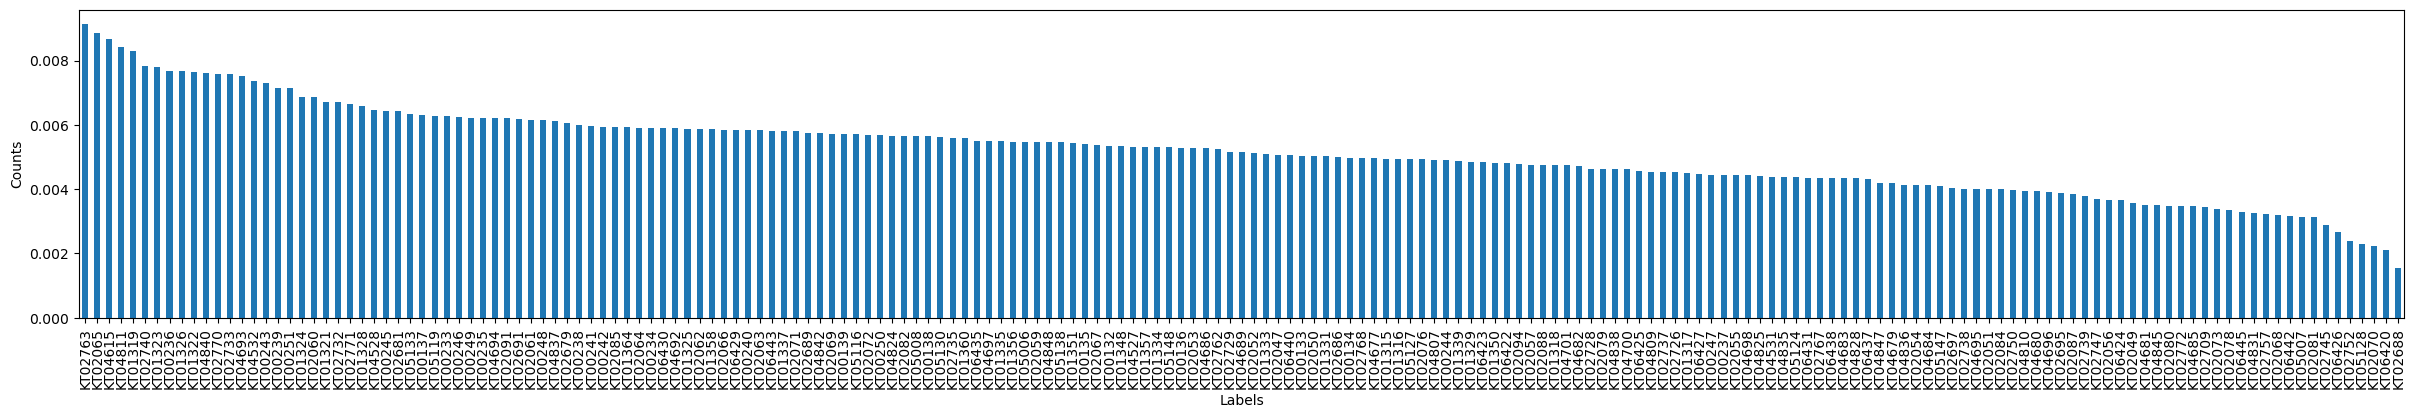

In [ ]:
# Normalized cell-count distribution across sample kit IDs
plt.style.use('default')
plt.figure(figsize=(30, 4))
adata.obs['sample.sampleKitGuid'].value_counts(normalize=True).plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.show()

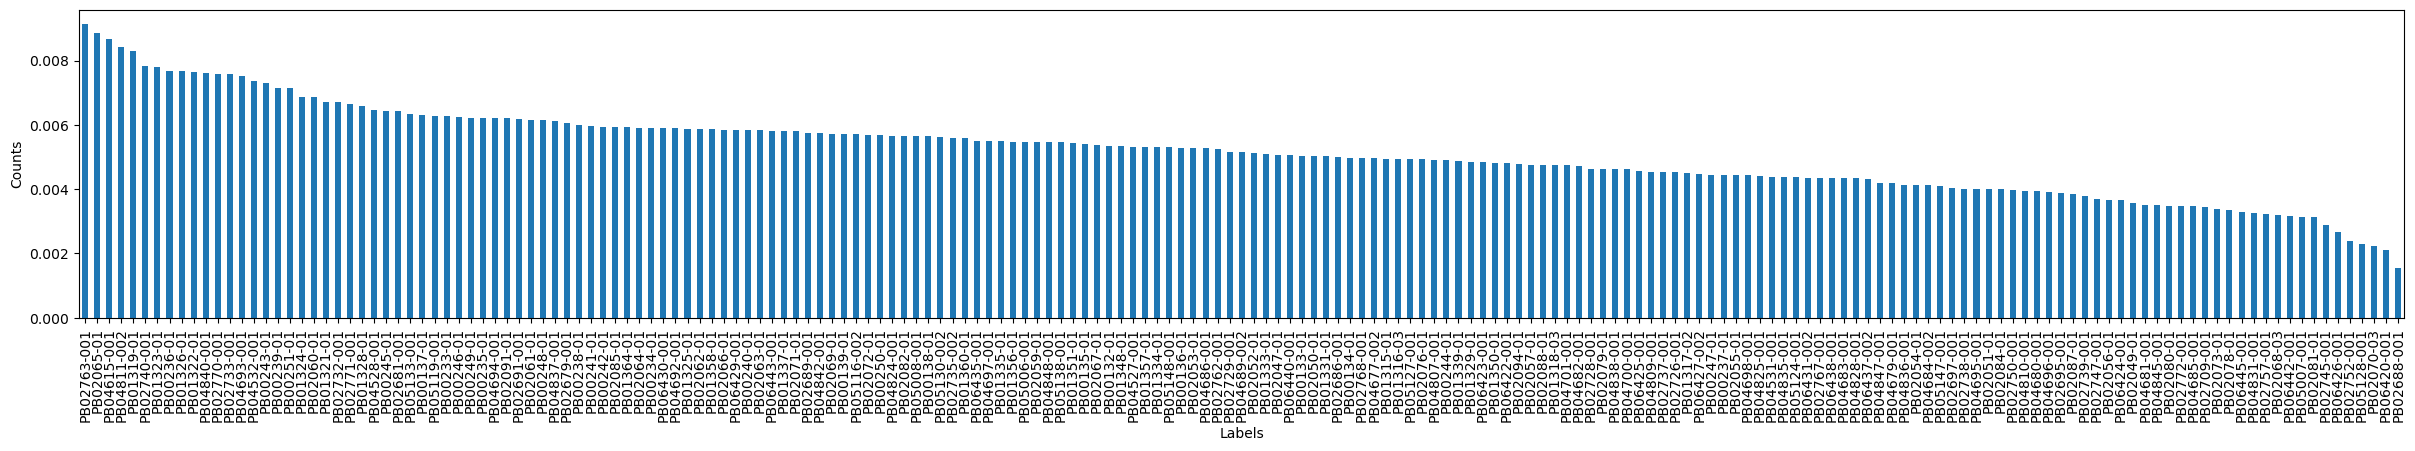

In [ ]:
# Normalized cell-count distribution across PBMC sample IDs
plt.style.use('default')
plt.figure(figsize=(30, 4))
adata.obs['pbmc_sample_id'].value_counts(normalize=True).plot(kind='bar')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.show()

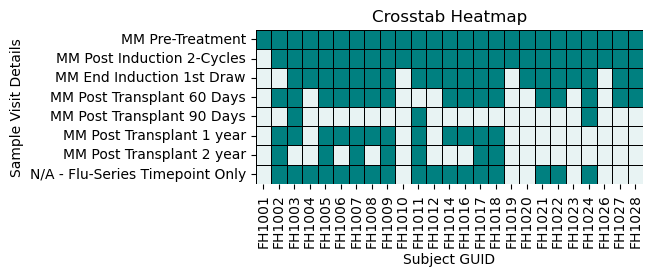

In [ ]:
# Define expected visit order for the PBMC treatment + flu timepoints
pbmc_tx_tp = adata.obs["sample.visitDetails"].cat.categories.tolist() \
    if hasattr(adata.obs["sample.visitDetails"], "cat") \
    else sorted(adata.obs["sample.visitDetails"].unique())

# Extract unique subject × visit combinations
data = adata.obs[["subject.subjectGuid", "sample.visitDetails"]].drop_duplicates()

# Set visit details as an ordered categorical for consistent axis ordering
data["sample.visitDetails"] = pd.Categorical(
    data["sample.visitDetails"], categories=pbmc_tx_tp, ordered=True
)

# Create contingency table (crosstab) of visit details by subject
crosstab = pd.crosstab(data["sample.visitDetails"], data["subject.subjectGuid"])

# Heatmap showing which subjects have data at each visit
plt.figure(figsize=(5, 2))
sns.heatmap(
    crosstab,
    annot=False,
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    cmap=sns.light_palette("teal", as_cmap=True),
)
plt.title("Crosstab Heatmap")
plt.ylabel("Sample Visit Details")
plt.xlabel("Subject GUID")
plt.show()

## 3 Apply QC Filtering

In [ ]:
# Run QC filtering and collect per-step cell counts
filter_counts = []
group_counts = apply_qc_filters(
    adata,
    max_mito=max_mito,
    min_genes=min_genes,
    max_genes=max_genes,
)
print(group_counts)

filter_counts.append(group_counts)

   n_start  n_doublets  n_singlets  n_high_mito  n_low_mito  n_low_genes  \
0  3212290       37227     3175063       219134     2955929         8423   

   n_above_min_genes  n_high_genes  n_below_max_genes  total_removed  n_final  
0            2947506          2732            2944774         267516  2944774  


In [51]:
all_filter_counts = pd.concat(filter_counts)
all_filter_counts
     

,n_start,n_doublets,n_singlets,n_high_mito,n_low_mito,n_low_genes,n_above_min_genes,n_high_genes,n_below_max_genes,total_removed,n_final
0,3212290,37227,3175063,219134,2955929,8423,2947506,2732,2944774,267516,2944774
